# Sesión 2 — Flujo de carga AC con Pandapower

**Objetivo:** Ejecutar y analizar el flujo de carga AC sobre la red IEEE 14. Entender la Ybus como estructura central del problema y comparar resultados con el caso base.

**Duración estimada:** 90 minutos

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandapower as pp
import pandapower.networks as pn
import networkx as nx
from IPython.display import display

print('Entorno listo ✓')

Entorno listo ✓


---
## 1. Carga de la red y primer flujo de carga

La red IEEE 14 barras modela una porción simplificada del sistema eléctrico del noreste de EE.UU. en 1962. Tiene 14 barras, 20 ramas y 5 generadores.

In [4]:
# Cargar la red
net = pn.case14()

# Ejecutar flujo de carga AC (método Newton-Raphson por defecto)
pp.runpp(net)

# Resultados en barras
print('--- Resultados en barras ---')
display(net.res_bus.round(4))

# TODO: ¿Cuántas iteraciones necesitó Newton-Raphson para converger?
# Pista: net._ppc['iterations']
# print('\nIteraciones NR: {}'.format())
iteraciones = net._ppc['iterations']
print('\nIteraciones NR: {}'.format(iteraciones))

--- Resultados en barras ---


,vm_pu,va_degree,p_mw,q_mvar
0,1.0600,0.0000,-232.3933,16.5493
1,1.0450,-4.9826,-18.3000,-30.8571
2,1.0100,-12.7251,94.2000,-6.0753
3,1.0177,-10.3129,47.8000,-3.9000
4,1.0195,-8.7739,7.6000,1.6000
5,1.0700,-14.2209,11.2000,-5.2309
6,1.0615,-13.3596,0.0000,0.0000
7,1.0900,-13.3596,0.0000,-17.6235
8,1.0559,-14.9385,29.5000,-4.5848
9,1.0510,-15.0973,9.0000,5.8000



Iteraciones NR: 3


### 1.1 Análisis de tensiones

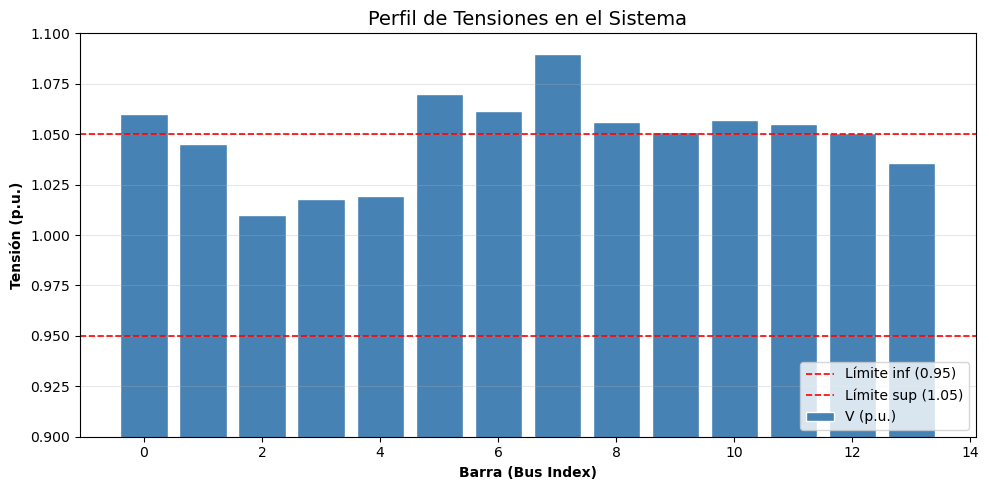

In [16]:
# TODO: representa gráficamente el perfil de tensiones (vm_pu) en todas las barras
# Añade líneas horizontales en 0.95 y 1.05 pu (límites habituales de operación)

# 1. Creamos la figura con un solo eje
fig, ax = plt.subplots(figsize=(10, 5))

# Dibujamos el perfil de tensiones
ax.bar(net.res_bus.index, net.res_bus['vm_pu'], color='steelblue', edgecolor='white', label='V (p.u.)')

# Añadimos líneas de límites operativos
ax.axhline(0.95, color='red', linestyle='--', linewidth=1.2, label='Límite inf (0.95)')
ax.axhline(1.05, color='red', linestyle='--', linewidth=1.2, label='Límite sup (1.05)')

# Configuración de etiquetas y diseño
ax.set_xlabel('Barra (Bus Index)', fontweight='bold')
ax.set_ylabel('Tensión (p.u.)', fontweight='bold')
ax.set_title('Perfil de Tensiones en el Sistema', fontsize=14)
ax.set_ylim(0.9, 1.1)  # Ajustamos el zoom para ver bien los límites
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='lower right')

# 4. Guardar y mostrar
plt.tight_layout()
plt.savefig('sesion02_perfil_tensiones_unico.png', dpi=150)
plt.show()


---
## 2. La matriz de admitancias nodales Ybus

La Ybus es el corazón matemático del flujo de carga. Es una matriz compleja y dispersa (la mayoría de sus elementos son cero) que representa la topología y los parámetros eléctricos de la red.


In [19]:
# Obtener la Ybus desde Pandapower
from pandapower.pd2ppc import _pd2ppc
from pandapower.shortcircuit.impedance import _calc_ybus

pp.runpp(net)
ppc, ppci = _pd2ppc(net)
_calc_ybus(ppci)
Ybus = ppci['internal']['Ybus'].todense()
Sbase = ppci['baseMVA']

print(f'Dimensión de Ybus: {Ybus.shape}')
print(f'Potencia base: {Sbase} MVA')

# TODO: calcula el número de condición de la Ybus
# (usa np.linalg.cond sobre la parte real)
cond = round(np.linalg.cond(Ybus.real,1), 4)
print(f'Número de condición (parte real): {cond:.2f}')

Dimensión de Ybus: (14, 14)
Potencia base: 100 MVA
Número de condición (parte real): inf


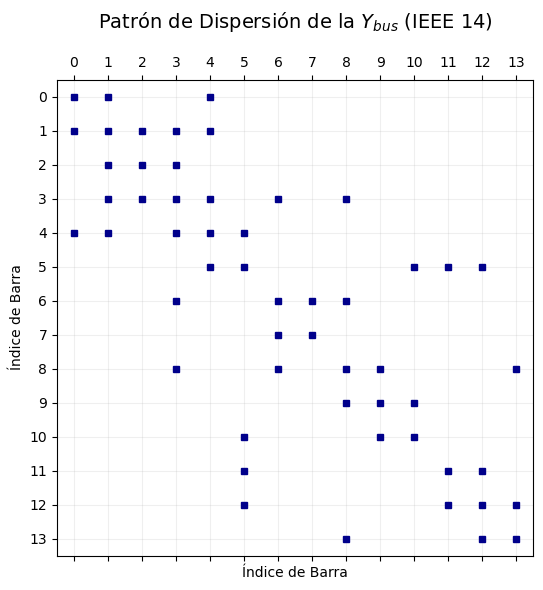

In [21]:
# Visualizar el patrón de dispersión de Ybus
# (qué elementos son no nulos = dónde hay conexiones entre barras)

# TODO: usa ax.spy() o plt.imshow(np.abs(Ybus)) para visualizar el patrón
# La dispersión de la Ybus refleja directamente la topología de la red
# Visualizar el patrón de dispersión de Ybus
fig, ax = plt.subplots(figsize=(6, 6))

ax.spy(Ybus, precision=1e-6, markersize=5, color='darkblue')

# Configuración formato
ax.set_title('Patrón de Dispersión de la $Y_{bus}$ (IEEE 14)', fontsize=14, pad=20)
ax.set_xlabel('Índice de Barra')
ax.set_ylabel('Índice de Barra')

# Añadimos rejilla para contar mejor las barras
ax.set_xticks(range(Ybus.shape[0]))
ax.set_yticks(range(Ybus.shape[0]))
ax.grid(True, alpha=0.2)

plt.tight_layout()

plt.savefig('../resultados/sesion02_patron_Ybus.png', dpi=150)
plt.show()

---
## 3. Análisis de flujos en líneas

In [22]:
# Resultados en líneas
display(net.res_line[['p_from_mw', 'q_from_mvar', 'pl_mw', 'loading_percent']].round(2))

# TODO: ¿qué línea está más cargada (loading_percent más alto)?
idx_max = net.res_line['loading_percent'].idxmax()
print(f'\nLínea más cargada: {idx_max} con {net.res_line.loc[idx_max, "loading_percent"]:.1f}% de carga')

# TODO: ¿qué líneas tienen pérdidas superiores a 0.5 MW?
lineas_perdidas = net.res_line[net.res_line['pl_mw'] > 0.5]
display(lineas_perdidas)

,p_from_mw,q_from_mvar,pl_mw,loading_percent
0,156.88,-20.40,4.30,1.51
1,75.51,3.85,2.76,0.72
2,73.24,3.56,2.32,0.71
3,56.13,-1.55,1.68,0.54
4,41.52,1.17,0.90,0.40
5,-23.29,4.47,0.37,0.24
6,-61.16,15.82,0.51,0.63
7,7.35,3.56,0.06,0.08
8,7.79,2.50,0.07,0.08
9,17.75,7.22,0.21,0.18



Línea más cargada: 0 con 1.5% de carga


,p_from_mw,q_from_mvar,p_to_mw,q_to_mvar,pl_mw,ql_mvar,i_from_ka,i_to_ka,i_ka,vm_from_pu,va_from_degree,vm_to_pu,va_to_degree,loading_percent
0,156.882891,-20.404292,-152.585290,27.676250,4.297600,7.271958,0.638290,0.634645,0.638290,1.060000,0.000000,1.045000,-4.982589,1.507568
1,75.510382,3.854991,-72.747509,2.229359,2.762873,6.084350,0.305050,0.305305,0.305305,1.060000,0.000000,1.019514,-8.773854,0.721097
2,73.237579,3.560203,-70.914310,1.602233,2.323269,5.162436,0.300079,0.300351,0.300351,1.045000,-4.982589,1.010000,-12.725100,0.709395
3,56.131496,-1.550350,-54.454838,3.020687,1.676658,1.470337,0.229806,0.229193,0.229806,1.045000,-4.982589,1.017671,-10.312901,0.542776
4,41.516215,1.170998,-40.612462,-2.099034,0.903753,-0.928036,0.169973,0.170589,0.170589,1.045000,-4.982589,1.019514,-8.773854,0.402912
6,-61.158230,15.823642,61.672650,-14.201005,0.514420,1.622637,0.265475,0.265475,0.265475,1.017671,-10.312901,1.019514,-8.773854,0.627022


---
## 4. Análisis de contingencias N-1

El criterio N-1 establece que el sistema debe seguir operando correctamente tras la salida de cualquier elemento. Simularemos la salida de la línea más cargada.

Contingencia activada: Línea 0 fuera de servicio.


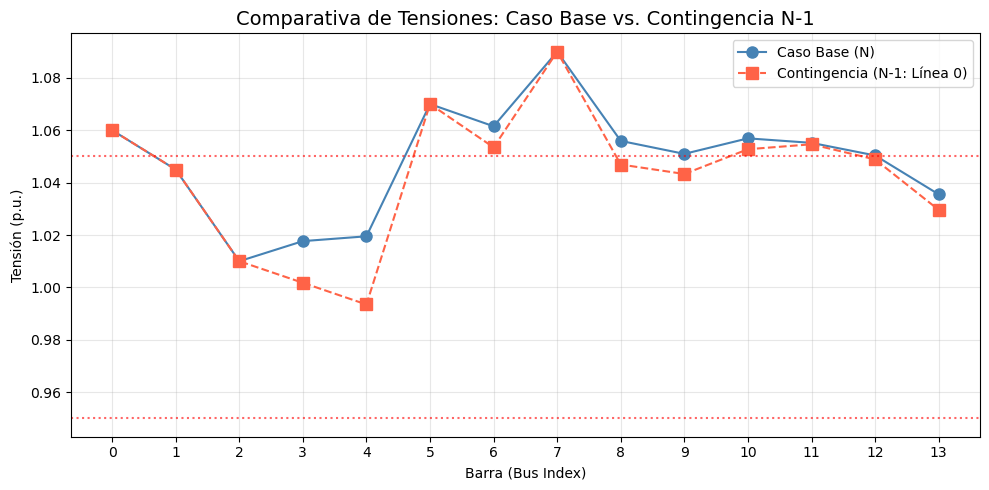

In [23]:
# Caso base: guardar tensiones
v_base = net.res_bus['vm_pu'].copy()

# Contingencia: desconectar la línea más cargada
net_n1 = pn.case14()  # red fresca

# TODO: desconectar la línea más cargada (net_n1.line.loc[idx_max, 'in_service'] = False)
net_n1.line.loc[idx_max, 'in_service'] = False
print(f'Contingencia activada: Línea {idx_max} fuera de servicio.')

# TODO: ejecutar el flujo de carga en la red con contingencia
pp.runpp(net_n1)

# TODO: comparar tensiones antes y después de la contingencia
# Grafica ambos perfiles en la misma figura
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(net.res_bus.index, v_base, 'o-', label='Caso Base (N)', color='steelblue', markersize=8)
ax.plot(net_n1.res_bus.index, net_n1.res_bus['vm_pu'], 's--', label=f'Contingencia (N-1: Línea {idx_max})', color='tomato', markersize=8)

# Añadimos los límites de operación para referencia
ax.axhline(0.95, color='red', linestyle=':', alpha=0.6)
ax.axhline(1.05, color='red', linestyle=':', alpha=0.6)

# Configuración estética
ax.set_title('Comparativa de Tensiones: Caso Base vs. Contingencia N-1', fontsize=14)
ax.set_xlabel('Barra (Bus Index)')
ax.set_ylabel('Tensión (p.u.)')
ax.set_xticks(net.res_bus.index)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('sesion02_contingencia_n1.png', dpi=150)
plt.show()

---
## 5. Redes en NetworkX


DiGraph with 6 nodes and 8 edges


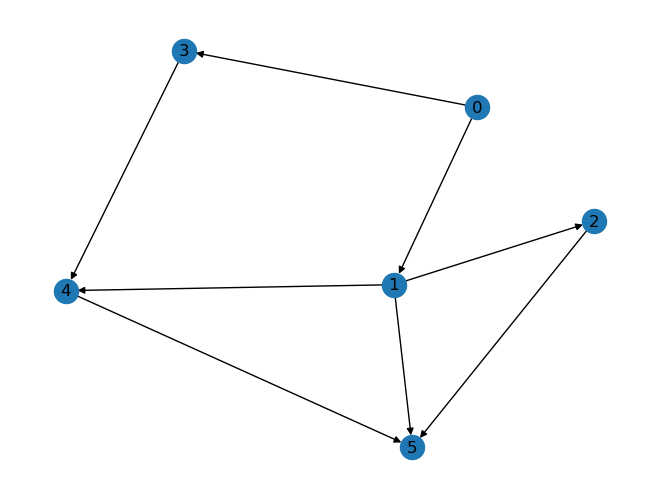

In [24]:
import networkx as nx
G = nx.DiGraph()
G.add_nodes_from([0,1,2,3,4,5])
G.add_edges_from([(0,1),(0,3),(1,2),(1,4),(1,5),(2,5),(3,4),
(4,5)])
print(G)

nx.draw(G,with_labels = True)

The node-branch indicence matrix A

In [25]:
A = nx.incidence_matrix(G,oriented = True)
print(A.toarray())


[[-1. -1.  0.  0.  0.  0.  0.  0.]
 [ 1.  0. -1. -1. -1.  0.  0.  0.]
 [ 0.  0.  1.  0.  0. -1.  0.  0.]
 [ 0.  1.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  1.  0.  0.  1. -1.]
 [ 0.  0.  0.  0.  1.  1.  0.  1.]]


The bus admittance matrix can be computed as:

$ Y_{bus} = 𝐴\times Y_B\times A^T$,

where $Y_B$ is a diagonal matrix containing the branch admittances.

Suppose that all branches have $Y_{branch}$ equal to $0.1+0.5j$, then the $Y_{bus}$ is computed as:

In [26]:
Ybranch = 0.1+0.5j
Y_B = Ybranch*np.identity(8)
Ybus = A @ Y_B @ A.T
print(Ybus)
print('The dimension of Ybus is: ', Ybus.shape)

[[ 0.2+1.j  -0.1-0.5j  0. +0.j  -0.1-0.5j  0. +0.j   0. +0.j ]
 [-0.1-0.5j  0.4+2.j  -0.1-0.5j  0. +0.j  -0.1-0.5j -0.1-0.5j]
 [ 0. +0.j  -0.1-0.5j  0.2+1.j   0. +0.j   0. +0.j  -0.1-0.5j]
 [-0.1-0.5j  0. +0.j   0. +0.j   0.2+1.j  -0.1-0.5j  0. +0.j ]
 [ 0. +0.j  -0.1-0.5j  0. +0.j  -0.1-0.5j  0.3+1.5j -0.1-0.5j]
 [ 0. +0.j  -0.1-0.5j -0.1-0.5j  0. +0.j  -0.1-0.5j  0.3+1.5j]]
The dimension of Ybus is:  (6, 6)


---
## Reflexión final

_Responde brevemente en esta celda:_

1. ¿Cómo cambia el perfil de tensiones tras la contingencia N-1? ¿El sistema sigue dentro de los límites operativos (±5%)?

Tras la desconexión de la línea más cargada (Línea 0), se observa una caída generalizada en los módulos de tensión, especialmente notable en las barras 3 y 4. Esto ocurre porque la potencia debe redistribuirse por caminos con mayor impedancia equivalente.

Respecto a los límites: No, el sistema no cumple estrictamente el límite superior en todos los nodos. Aunque ninguna barra cae por debajo del límite inferior (0.95 p.u.), varias barras (como la 0, 5, 7,8, 10, 11) ya estaban por encima de 1.05 p.u. en el caso base y se mantienen ahí o fluctúan ligeramente tras la contingencia


2. La matriz Ybus es **dispersa** (sparse). ¿Por qué es importante esta propiedad para resolver el flujo de carga en redes grandes?]

Al realizar la factorizacion LU y reorganizacion de la matriz nos permite agilizar el proceso de calculo y asi poder realizar el flujo de carga en un menor tiempo 


3. Newton-Raphson converge cuadráticamente cerca de la solución. ¿Observas ese comportamiento en el número de iteraciones?
Si dado que converge en tan solo 3 iteraciones. 